This should be updated to match the layers_similarity

[Safety Layers in Aligned Large Language Models: The Key to LLM Security](https://arxiv.org/abs/2408.17003) \
this paper basically says that safety is tuned for in specific layers and it finds those layers \
we can use this to find the layers that account for safety in gemma3-1b-it and also perhaps a similar method to see if we can locate layers for utility

# imports

In [ ]:
import torch
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
import layers_similarity

# load activations

In [2]:
harmful_g = np.load("activations/harmful_activations.npy")
harmless_g = np.load("activations/harmless_activations.npy")
utility_g = np.load("activations/utility_activations.npy")

harmful_mi = np.load("activations/harmful_activations_mistralit.npy")
harmless_mi = np.load("activations/harmless_activations_mistralit.npy")
utility_mi = np.load("activations/utility_activations_mistralit.npy")

harmful_g2b = np.load("activations/harmful_2b_activations.npy")
harmless_g2b = np.load("activations/harmless_2b_activations.npy")
utility_g2b = np.load("activations/utility_2b_activations.npy")

In [3]:
def cosine_similarity(A, B):
    dot = np.dot(A, B)
    norm = np.linalg.norm(A) * np.linalg.norm(B)
    return dot / norm

the following part corresponds to section 3.2 of the paper
what this section basically aims to find is where or how deep does the model begin exhibiting safety behaviour? so basically as we go deeper into the model where does it begin distinguishing between harmful and harmless prompts? \
in this section they input N (normal) and M (malicous) prompts, and get the activations (We already did this for gemma3-1b-it), see analyze_model_layers.ipynb \
calculate cosine similarity for all possible pairs, both normal, one normal one malicious and both malicious, for all layers, we implement this below \
repeat this many times

In [ ]:
r = 500

def layer_cosine_sim(act1, act2):
    return [cosine_similarity(act1[k], act2[k]) for k in range(len(act1))]

def analysis(acts1, acts2, r):
    results = []
    for _ in range(r):
        i = np.random.randint(len(acts1))
        j = np.random.randint(len(acts2))
        if acts1 is acts2:
            while j == i:
                j = np.random.randint(len(acts1))
        results.append(layer_cosine_sim(acts1[i], acts2[j]))
    results = np.array(results)
    return results.mean(axis=0), results.std(axis=0)

nn_mean, nn_std = analysis(harmless_g, harmless_g, r)
mm_mean, mm_std = analysis(harmful_g, harmful_g, r)
nm_mean, nm_std = analysis(harmless_g, harmful_g, r)

# gemma3-1b-it

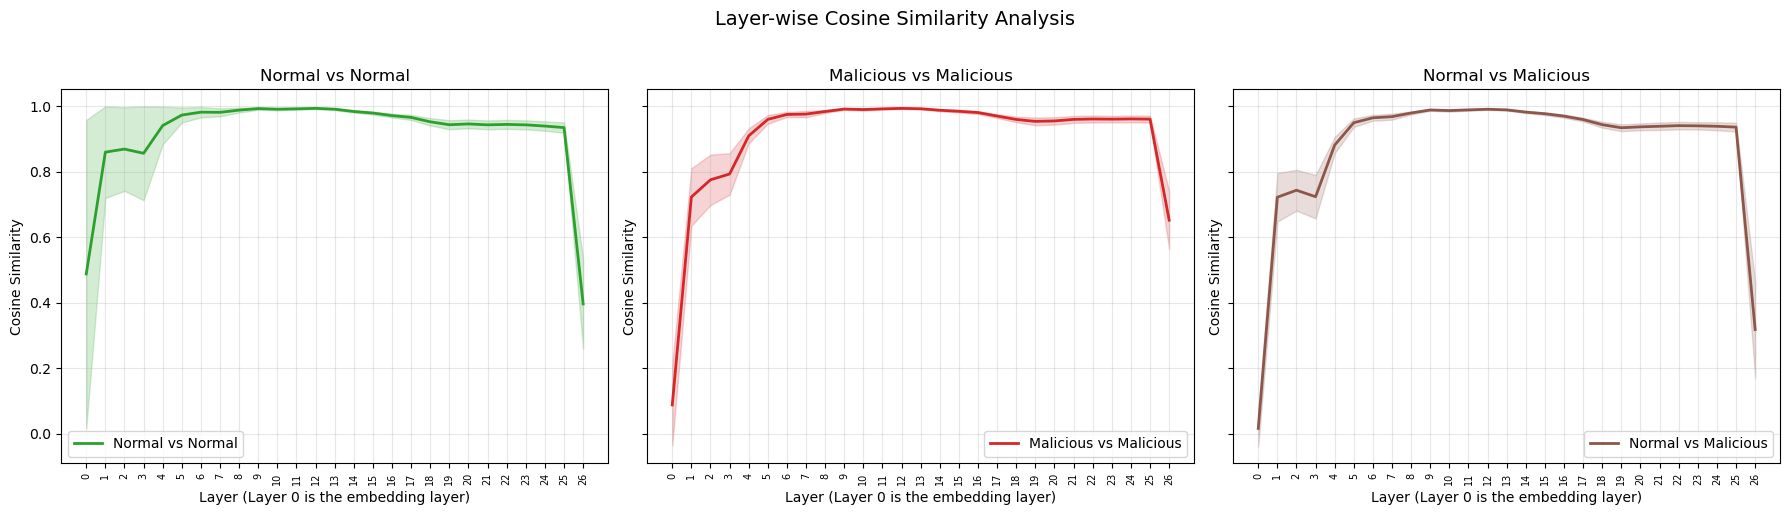

In [ ]:
layers = np.arange(len(nn_mean))
layer_labels = [str(i) for i in range(0, len(nn_mean))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    ("Normal vs Normal", nn_mean, nn_std, "tab:green"),
    ("Malicious vs Malicious", mm_mean, mm_std, "tab:red"),
    ("Normal vs Malicious", nm_mean, nm_std, "tab:brown"),
]

for ax, (title, mean, std, color) in zip(axes, configs):
    ax.plot(layers, mean, color=color, linewidth=2, label=title)
    ax.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(title)
    ax.set_xticks(layers)
    ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Cosine Similarity of Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

We can see that on activations testing both, normal and malicious prompts

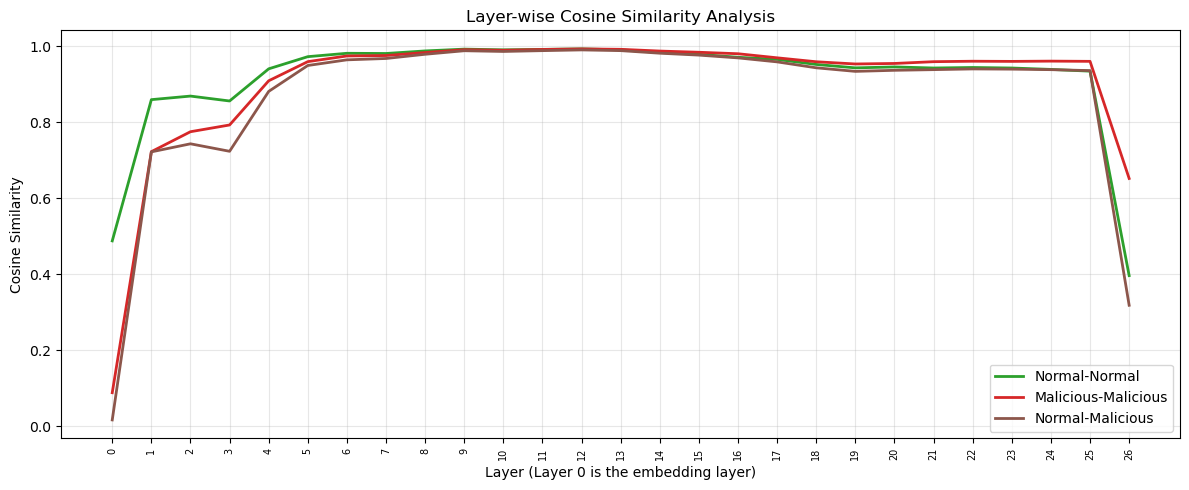

In [6]:
layers = np.arange(len(nn_mean))
layer_labels = [str(i) for i in range(0, len(nn_mean))]

fig, ax = plt.subplots(figsize=(12, 5))

configs = [
    ("Normal-Normal", nn_mean, nn_std, "tab:green"),
    ("Malicious-Malicious", mm_mean, mm_std, "tab:red"),
    ("Normal-Malicious", nm_mean, nm_std, "tab:brown"),
]

for title, mean, std, color in configs:
    ax.plot(layers, mean, color=color, linewidth=2, label=title)

ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Layer-wise Cosine Similarity Analysis")
ax.set_xticks(layers)
ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# mistral 7b instruct v0.1

In [7]:
nn_mean_mi, nn_std_mi = analysis(harmless_mi, harmless_mi, r)
mm_mean_mi, mm_std_mi = analysis(harmful_mi, harmful_mi, r)
nm_mean_mi, nm_std_mi = analysis(harmless_mi, harmful_mi, r)

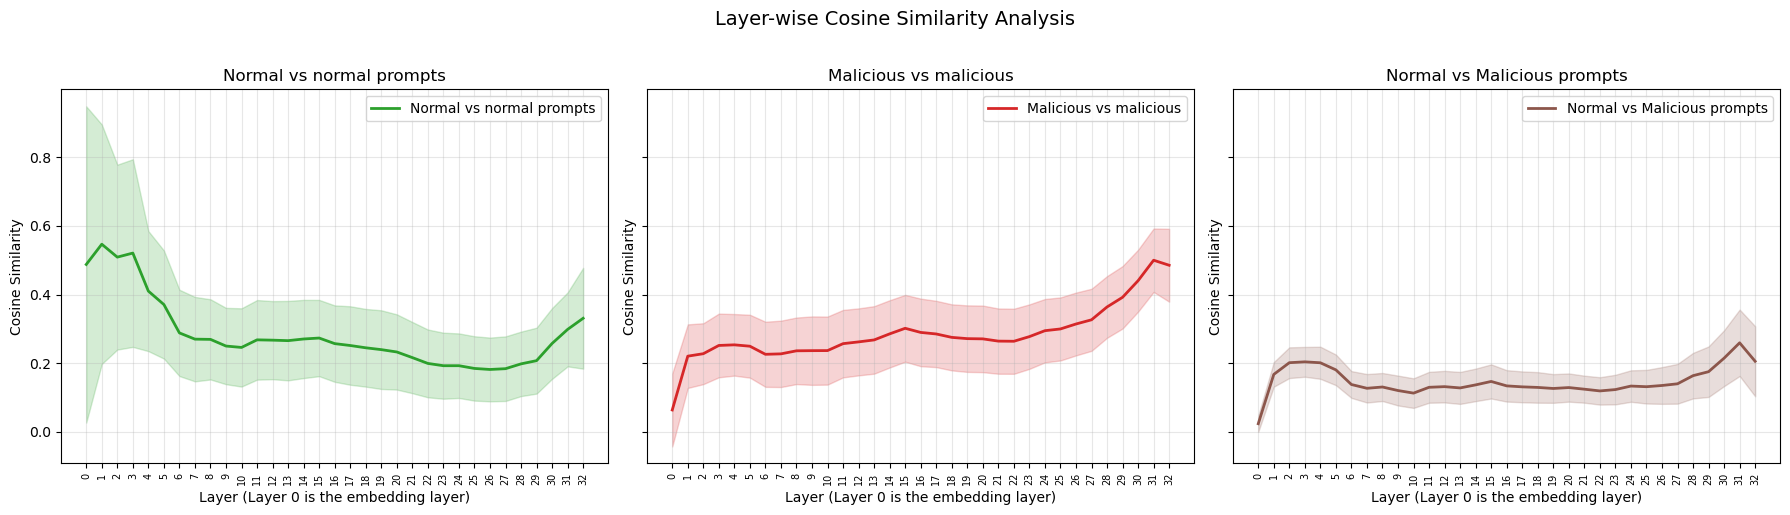

In [8]:
layers = np.arange(len(nn_mean_mi))
layer_labels = [str(i) for i in range(0, len(nn_mean_mi))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    ("Normal vs normal prompts", nn_mean_mi, nn_std_mi, "tab:green"),
    ("Malicious vs malicious", mm_mean_mi, mm_std_mi, "tab:red"),
    ("Normal vs Malicious prompts", nm_mean_mi, nm_std_mi, "tab:brown"),
]

for ax, (title, mean, std, color) in zip(axes, configs):
    ax.plot(layers, mean, color=color, linewidth=2, label=title)
    ax.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(title)
    ax.set_xticks(layers)
    ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Cosine Similarity Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

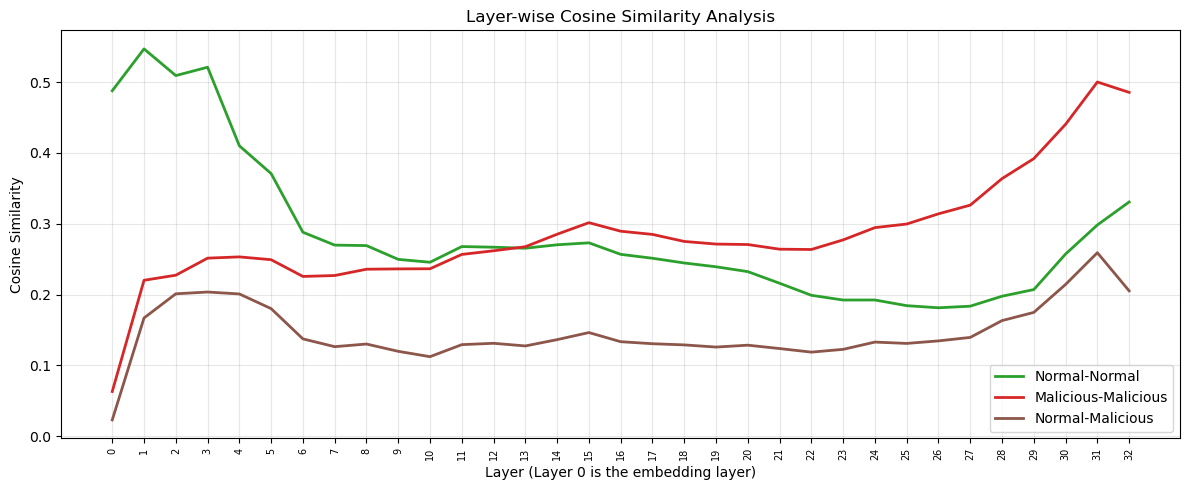

In [9]:
layers = np.arange(len(nn_mean_mi))
layer_labels = [str(i) for i in range(0, len(nn_mean_mi))]

fig, ax = plt.subplots(figsize=(12, 5))

configs = [
    ("Normal-Normal", nn_mean_mi, nn_std_mi, "tab:green"),
    ("Malicious-Malicious", mm_mean_mi, mm_std_mi, "tab:red"),
    ("Normal-Malicious", nm_mean_mi, nm_std_mi, "tab:brown"),
]

for title, mean, std, color in configs:
    ax.plot(layers, mean, color=color, linewidth=2, label=title)

ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Layer-wise Cosine Similarity Analysis")
ax.set_xticks(layers)
ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gemma2b-it

In [10]:
nn_mean_g2b, nn_std_g2b = analysis(harmless_g2b, harmless_g2b, r)
mm_mean_g2b, mm_std_g2b = analysis(harmful_g2b, harmful_g2b, r)
nm_mean_g2b, nm_std_g2b = analysis(harmless_g2b, harmful_g2b, r)

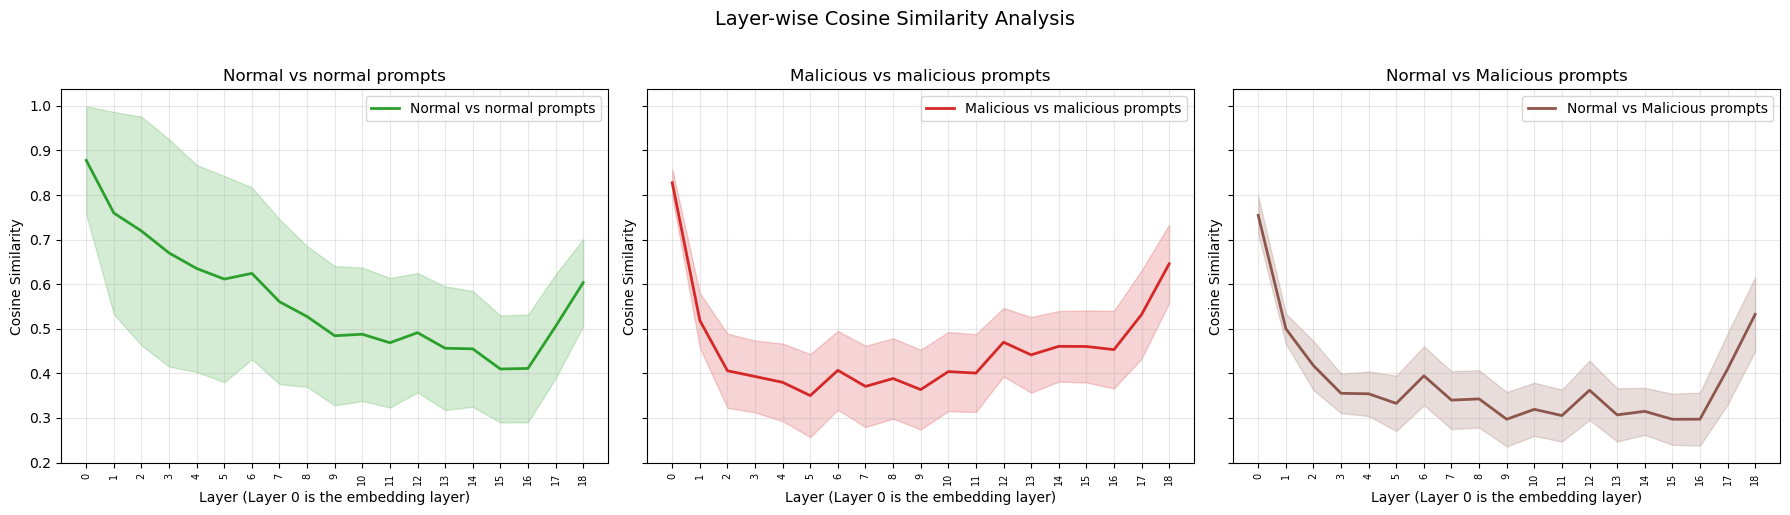

In [11]:
layers = np.arange(len(nn_mean_g2b))
layer_labels = [str(i) for i in range(0, len(nn_mean_g2b))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    ("Normal vs normal prompts", nn_mean_g2b, nn_std_g2b, "tab:green"),
    ("Malicious vs malicious prompts", mm_mean_g2b, mm_std_g2b, "tab:red"),
    ("Normal vs Malicious prompts", nm_mean_g2b, nm_std_g2b, "tab:brown"),
]

for ax, (title, mean, std, color) in zip(axes, configs):
    ax.plot(layers, mean, color=color, linewidth=2, label=title)
    ax.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(title)
    ax.set_xticks(layers)
    ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Cosine Similarity Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

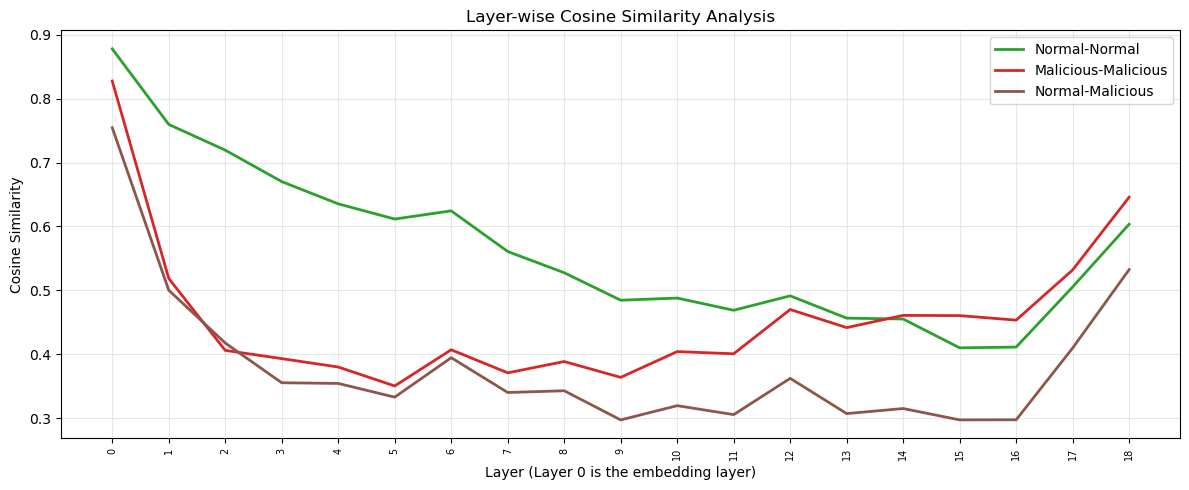

In [12]:
layers = np.arange(len(nn_mean_g2b))
layer_labels = [str(i) for i in range(0, len(nn_mean_g2b))]

fig, ax = plt.subplots(figsize=(12, 5))

configs = [
    ("Normal-Normal", nn_mean_g2b, nn_std_g2b, "tab:green"),
    ("Malicious-Malicious", mm_mean_g2b, mm_std_g2b, "tab:red"),
    ("Normal-Malicious", nm_mean_g2b, nm_std_g2b, "tab:brown"),
]

for title, mean, std, color in configs:
    ax.plot(layers, mean, color=color, linewidth=2, label=title)

ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Layer-wise Cosine Similarity Analysis")
ax.set_xticks(layers)
ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# gemma 2 2b it

In [13]:
harmful_g2 = np.load("activations/harmful_2_2b_activations.npy")
harmless_g2 = np.load("activations/harmless_2_2b_activations.npy")
utility_g2 = np.load("activations/utility_2_2b_activations.npy")


nn_mean_g2, nn_std_g2 = analysis(harmless_g2, harmless_g2, r)
mm_mean_g2, mm_std_g2 = analysis(harmful_g2, harmful_g2, r)
nm_mean_g2, nm_std_g2 = analysis(harmless_g2, harmful_g2, r)

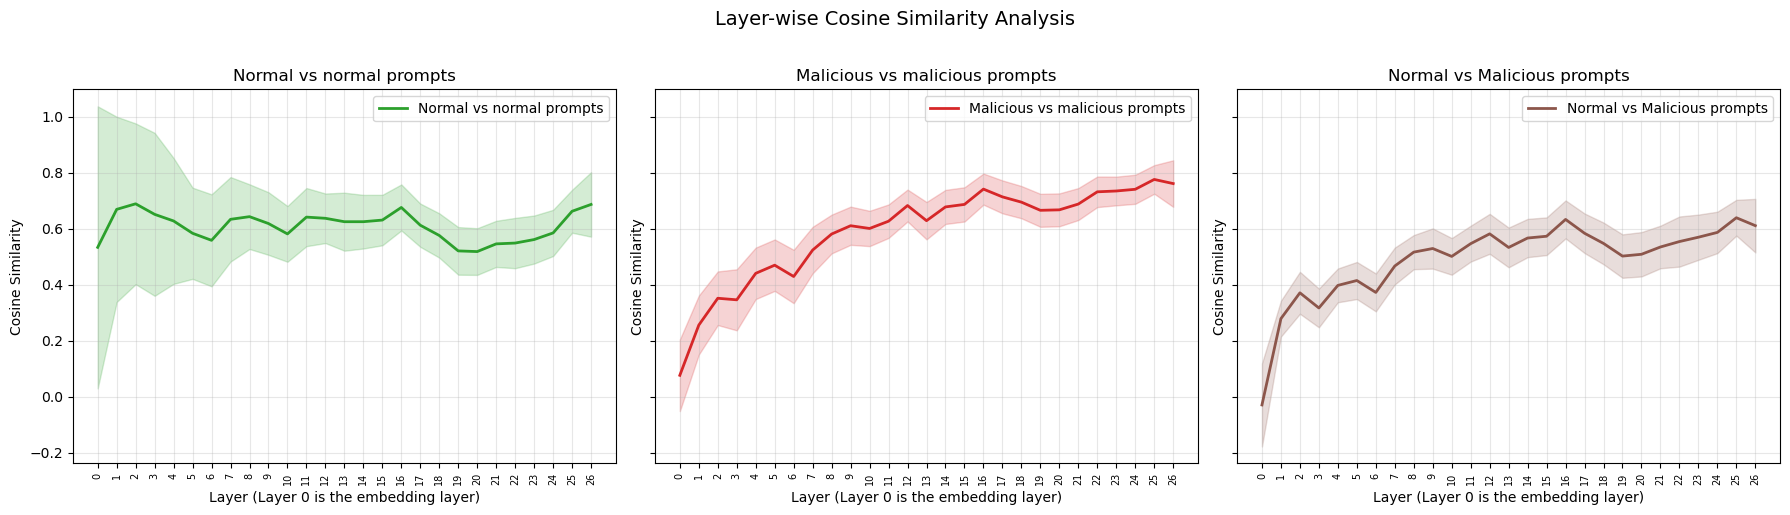

In [14]:
layers = np.arange(len(nn_mean_g2))
layer_labels = [str(i) for i in range(0, len(nn_mean_g2))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    ("Normal vs normal prompts", nn_mean_g2, nn_std_g2, "tab:green"),
    ("Malicious vs malicious prompts", mm_mean_g2, mm_std_g2, "tab:red"),
    ("Normal vs Malicious prompts", nm_mean_g2, nm_std_g2, "tab:brown"),
]

for ax, (title, mean, std, color) in zip(axes, configs):
    ax.plot(layers, mean, color=color, linewidth=2, label=title)
    ax.fill_between(layers, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(title)
    ax.set_xticks(layers)
    ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Cosine Similarity Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

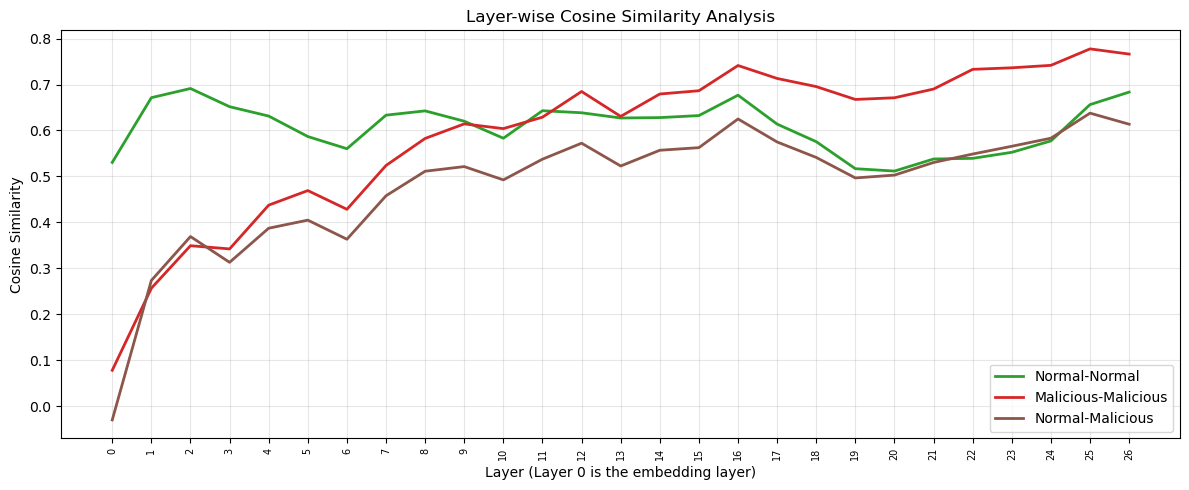

In [58]:
layers = np.arange(len(nn_mean_g2))
layer_labels = [str(i) for i in range(0, len(nn_mean_g2))]

fig, ax = plt.subplots(figsize=(12, 5))

configs = [
    ("Normal-Normal", nn_mean_g2, nn_std_g2, "tab:green"),
    ("Malicious-Malicious", mm_mean_g2, mm_std_g2, "tab:red"),
    ("Normal-Malicious", nm_mean_g2, nm_std_g2, "tab:brown"),
]

for title, mean, std, color in configs:
    ax.plot(layers, mean, color=color, linewidth=2, label=title)

ax.set_xlabel("Layer (Layer 0 is the embedding layer)")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Layer-wise Cosine Similarity Analysis")
ax.set_xticks(layers)
ax.set_xticklabels(layer_labels, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# This serves as a check for gemma3-1b-it, we try with gemma3-1b-pt

In [6]:
import os
import numpy as np 
import layers_similarity
os.getcwd()

'/home/khalidraisi/VSCode/Uni/NLP/project/code/locatelayers'

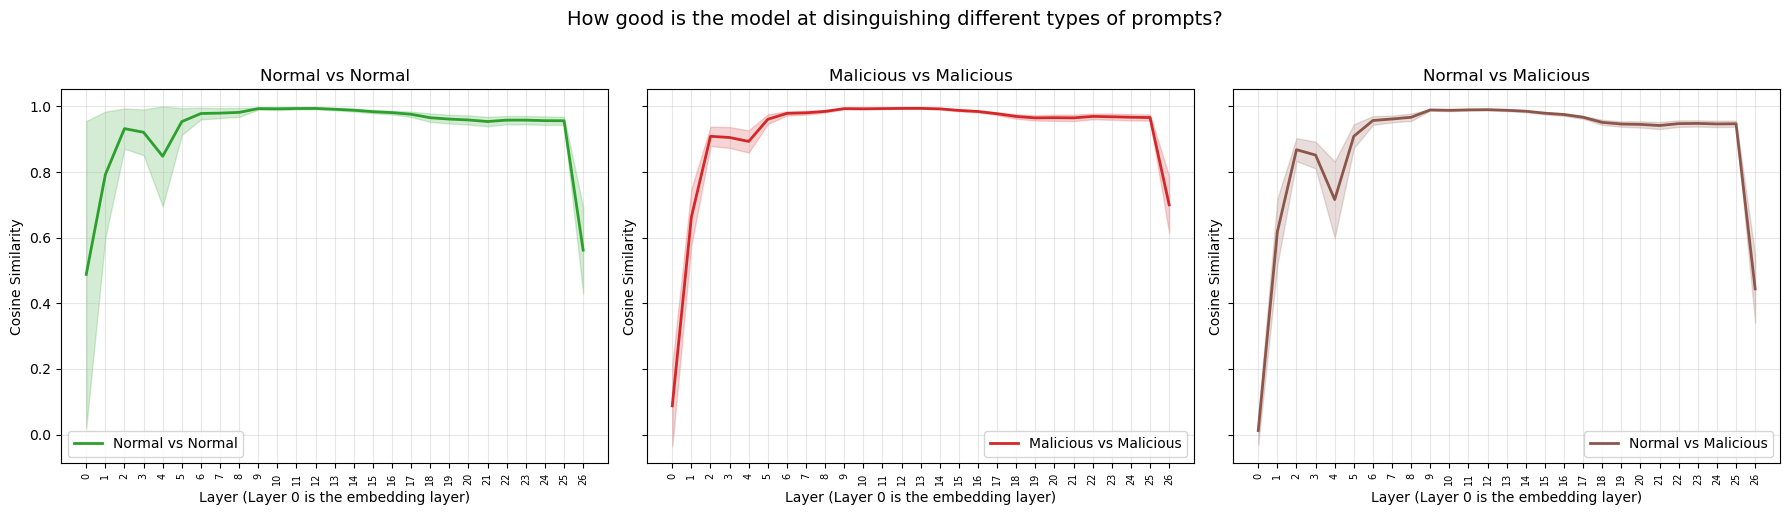

In [8]:
harmful_1b_pt = np.load("../activations/gemma3acts/pt/harmful_1b_pt_activations.npy")
harmless_1b_pt = np.load("../activations/gemma3acts/pt/harmless_1b_pt_activations.npy")
utility_1b_pt = np.load("../activations/gemma3acts/pt/utility_1b_pt_activations.npy")

layers_similarity.get_similarity_plot(harmless_1b_pt, harmful_1b_pt)

the drop in normal vs malicious seems to be smaller than compared to the it model? this is what you expect however this does not mean much we need to test this more